# CodeAlpha Task 2 — Exploratory Data Analysis
## Online Retail Dataset (UCI Machine Learning Repository)

**Author:** Ali Rashid (Chaudhary)
**Internship:** CodeAlpha Data Analytics Internship — Task 2 (EDA)

---

### Project Objective

Perform a complete, evidence-based exploratory data analysis on a real-world
transactional dataset: explore its structure, clean genuine data-quality
issues, uncover trends/patterns/anomalies, and validate assumptions with
statistical tests and visualizations — satisfying every requirement of the
CodeAlpha Task 2 brief.

### Dataset Information

| | |
|---|---|
| **Name** | Online Retail Dataset |
| **Source** | UCI Machine Learning Repository (donor: Dr. Daqing Chen, London South Bank University) — `archive.ics.uci.edu/dataset/352/online+retail` |
| **Description** | All transactions between 01/12/2010 and 09/12/2011 for a UK-based, non-store online retailer selling all-occasion gifts. Many customers are wholesalers. |
| **Size** | 541,909 rows × 8 columns (raw) |
| **License** | CC BY 4.0 |

### Analytical Questions

1. What is the overall distribution of order quantities and unit prices, and what does the skew imply about typical vs. bulk/wholesale transactions?
2. Which countries generate the most revenue, and how concentrated is that revenue?
3. Is there a seasonal/monthly trend in sales, particularly around the winter holiday season?
4. Which products are most frequently purchased vs. which generate the most revenue — are they the same products?
5. Do UK and non-UK transactions differ significantly in average line-item revenue? (t-test)
6. Does average invoice revenue differ significantly across quarters of the year? (ANOVA)
7. Is cancellation status associated with the customer's country? (chi-square test)
8. How correlated are Quantity and UnitPrice with each other and with total revenue?
9. What proportion of transactions are cancellations, and does the cancellation rate change over time?
10. Are there anomalous transactions (extreme quantity/price outliers) that deserve investigation?
11. What does customer purchase behavior look like through an RFM (Recency, Frequency, Monetary) lens?
12. What data-quality issues exist in the raw data, and how significant are they?


## 1. Import Libraries

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 2. Load Dataset

In [2]:
DATA_PATH = Path("../data/raw/OnlineRetail.xlsx")
df = pd.read_excel(DATA_PATH)
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns.")


Loaded 541,909 rows and 8 columns.


### First and Last Records

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


## 3. Dataset Overview

### 3.1 Dimensions, Columns, and Data Types


In [5]:
print("Dimensions (rows, columns):", df.shape)
print()
print("Columns:", list(df.columns))
print()
print(df.dtypes)


Dimensions (rows, columns): (541909, 8)

Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


**Finding:** The dataset has 8 raw columns. `InvoiceDate` is already a
datetime type; `CustomerID` is stored as float (because of missing values,
pandas cannot use an integer dtype); `Quantity` and `UnitPrice` are numeric
and ready for statistical analysis; `InvoiceNo`, `StockCode`, `Description`,
and `Country` are categorical/text fields.


### 3.2 Unique Values per Column

In [6]:
df.nunique().sort_values(ascending=False)

InvoiceNo      25900
InvoiceDate    23260
CustomerID      4372
Description     4223
StockCode       4070
UnitPrice       1630
Quantity         722
Country           38
dtype: int64

**Finding:** There are 38 unique countries, ~4,070 unique product (`StockCode`)
values, and ~4,372 unique customers — confirming this is a rich, multi-country,
multi-product transactional dataset well-suited for segmentation and
country/time-based analysis.


### 3.3 Numerical Summary Statistics

In [7]:
df[["Quantity", "UnitPrice"]].describe()

,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


**Finding:** `Quantity` ranges from a large negative number (returns) to
80,995 (a bulk/wholesale order), with a median of only 3 — most transaction
lines involve small quantities, but a long right tail of bulk orders pulls
the mean well above the median. `UnitPrice` shows the same pattern: median
£2.08 vs. a maximum of over £13,000, which is almost certainly a
non-product administrative charge rather than a genuine unit price — this is
investigated in the anomaly detection section.


### 3.4 Categorical Summary

In [8]:
print("Top 10 countries by transaction count:")
display(df["Country"].value_counts().head(10))
print()
print("Top 10 products by transaction count:")
display(df["Description"].value_counts().head(10))


Top 10 countries by transaction count:


Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64


Top 10 products by transaction count:


Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: count, dtype: int64

## 4. Data Quality Assessment

### 4.1 Missing Value Analysis


In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)


,missing_count,missing_pct
CustomerID,135080,24.93
Description,1454,0.27


**Finding:** `CustomerID` is missing in roughly a quarter of all rows —
these are legitimate sales to unregistered/guest checkouts, not corrupted
rows, so they cannot simply be dropped without losing real revenue data.
`Description` is missing in a very small fraction of rows, mostly tied to
non-product administrative entries.


### 4.2 Duplicate Analysis

In [10]:
n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows: {n_dupes:,} ({n_dupes/len(df)*100:.2f}% of the dataset)")
df[df.duplicated(keep=False)].astype({"InvoiceNo": str}).sort_values("InvoiceNo").head(6)


Exact duplicate rows: 5,268 (0.97% of the dataset)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom


**Finding:** Just under 1% of rows are exact duplicates (identical invoice,
product, quantity, price, date, customer, and country) — almost certainly a
data export/logging artifact rather than genuine repeat line items, so these
are safe to drop.


### 4.3 Data Quality Checks (Business-Rule Validation)

In [11]:
n_cancellations = df["InvoiceNo"].astype(str).str.startswith("C").sum()
n_neg_qty = (df["Quantity"] < 0).sum()
n_bad_price = (df["UnitPrice"] <= 0).sum()
non_cancel_neg_qty = ((df["Quantity"] < 0) & (~df["InvoiceNo"].astype(str).str.startswith("C"))).sum()

print(f"Cancellation invoices (InvoiceNo starting with 'C'): {n_cancellations:,} ({n_cancellations/len(df)*100:.2f}%)")
print(f"Rows with negative Quantity:                          {n_neg_qty:,}")
print(f"Rows with zero/negative UnitPrice:                    {n_bad_price:,}")
print(f"Negative-quantity rows that are NOT flagged cancels:  {non_cancel_neg_qty:,}")


Cancellation invoices (InvoiceNo starting with 'C'): 9,288 (1.71%)
Rows with negative Quantity:                          10,624
Rows with zero/negative UnitPrice:                    2,517
Negative-quantity rows that are NOT flagged cancels:  1,336


**Finding:** Roughly 1.7% of invoices are cancellations (returns), which
legitimately carry negative quantities. However, over a thousand rows have
negative quantities **without** an accompanying "C" invoice prefix — these
look like stock adjustments or data-entry inconsistencies that need
explicit handling rather than blind removal.


## 5. Data Cleaning

Each decision below states the problem, why it matters, the method used, and
why that method is appropriate. **No data is deleted blindly.**


In [12]:
df_clean = df.copy()

# 1) Flag cancellations BEFORE any filtering, so this information is preserved
df_clean["IsCancelled"] = df_clean["InvoiceNo"].astype(str).str.startswith("C")

# 2) Remove exact duplicate rows (logging/export artifact, not real repeat orders)
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - len(df_clean):,} exact duplicate rows.")

# 3) Missing Description (~0.27%): fill rather than drop, since dropping would
#    discard otherwise-valid transaction rows tied to a real StockCode.
df_clean["Description"] = df_clean["Description"].fillna("UNKNOWN ITEM")

# 4) Missing CustomerID (~25%): these are valid guest-checkout sales. Dropping
#    them would silently discard ~25% of revenue data, so they are KEPT for
#    product/country/time analysis and only EXCLUDED from customer-level
#    analysis (RFM), which requires a valid customer identity by definition.
df_clean["HasCustomerID"] = df_clean["CustomerID"].notnull()

# 5) Zero/negative UnitPrice on non-cancelled rows are not genuine product
#    sales (adjustments, samples, bank charges) — they would distort revenue
#    and correlation analysis, so they are excluded from the "valid sale"
#    view (flagged, not deleted, for transparency).
df_clean["IsValidSale"] = (df_clean["UnitPrice"] > 0) & (df_clean["Quantity"] > 0) & (~df_clean["IsCancelled"])

# 6) Correct data types
df_clean["InvoiceNo"] = df_clean["InvoiceNo"].astype(str)
df_clean["StockCode"] = df_clean["StockCode"].astype(str)
df_clean["CustomerID"] = df_clean["CustomerID"].astype("Int64")
df_clean["Country"] = df_clean["Country"].astype(str).str.strip()

# 7) Derived fields used throughout the rest of the analysis
df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]
df_clean["InvoiceMonth"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)
df_clean["InvoiceHour"] = df_clean["InvoiceDate"].dt.hour
df_clean["InvoiceDOW"] = df_clean["InvoiceDate"].dt.day_name()
df_clean["Quarter"] = df_clean["InvoiceDate"].dt.to_period("Q").astype(str)

print(f"\nFinal cleaned dataset: {len(df_clean):,} rows")
print(f"Valid sales rows (used for revenue analysis): {df_clean['IsValidSale'].sum():,}")


Removed 5,268 exact duplicate rows.



Final cleaned dataset: 536,641 rows
Valid sales rows (used for revenue analysis): 524,878


**Why these methods were chosen:** the guiding principle throughout is to
**preserve information via flags rather than deleting rows outright**,
since this dataset mixes genuine sales, returns, and administrative entries
that all carry analytical meaning. Only exact duplicate rows — which add no
information — are removed unconditionally.


## 6. Univariate Analysis

Analyzing individual variables in isolation: their distributions, spread,
and shape.


In [13]:
sales = df_clean[df_clean["IsValidSale"]]
print("Quantity:")
display(sales["Quantity"].describe())
print(f"Skewness: {sales['Quantity'].skew():.2f}")
print()
print("UnitPrice:")
display(sales["UnitPrice"].describe())
print(f"Skewness: {sales['UnitPrice'].skew():.2f}")


Quantity:


count    524878.000000
mean         10.616600
std         156.280031
min           1.000000
25%           1.000000
50%           4.000000
75%          11.000000
max       80995.000000
Name: Quantity, dtype: float64

Skewness: 469.54

UnitPrice:


count    524878.000000
mean          3.922573
std          36.093028
min           0.001000
25%           1.250000
50%           2.080000
75%           4.130000
max       13541.330000
Name: UnitPrice, dtype: float64

Skewness: 205.09


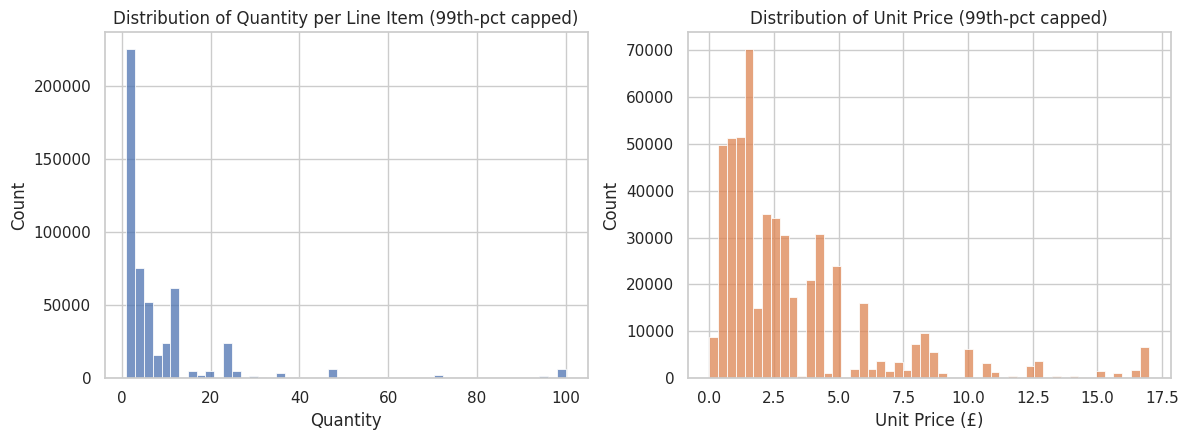

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(sales["Quantity"].clip(upper=sales["Quantity"].quantile(0.99)), bins=50, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Quantity per Line Item (99th-pct capped)")
axes[0].set_xlabel("Quantity")
sns.histplot(sales["UnitPrice"].clip(upper=sales["UnitPrice"].quantile(0.99)), bins=50, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribution of Unit Price (99th-pct capped)")
axes[1].set_xlabel("Unit Price (£)")
plt.tight_layout()
plt.show()


**Finding:** Both `Quantity` and `UnitPrice` are strongly right-skewed
(skew far above 1). Most line items are small, low-value purchases; a
smaller set of bulk/wholesale orders and a handful of very high unit prices
create a long right tail. This confirms the median (not the mean) is the
more representative "typical transaction" measure for this dataset.


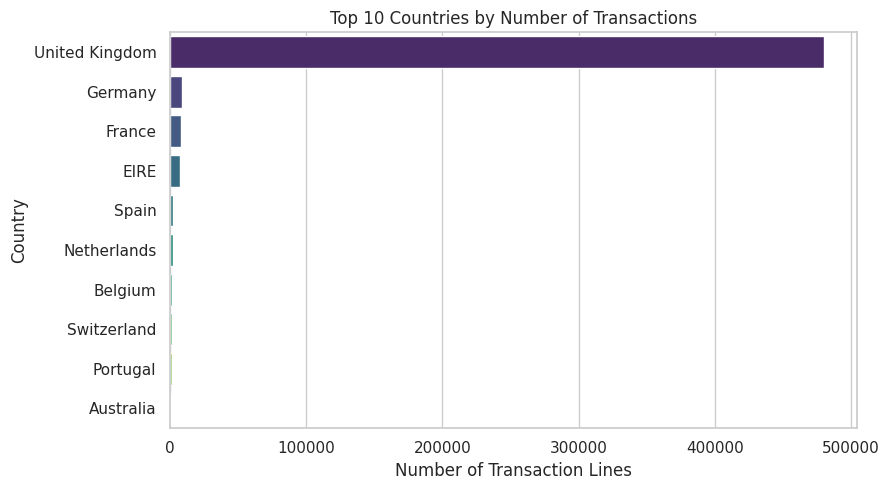

Country
United Kingdom    479985
Germany             9025
France              8392
EIRE                7879
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1958
Portugal            1492
Australia           1181
Name: count, dtype: int64

In [15]:
top_countries = sales["Country"].value_counts().head(10)
plt.figure(figsize=(9, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette="viridis", legend=False)
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Number of Transaction Lines")
plt.tight_layout()
plt.show()
top_countries


**Finding:** The United Kingdom dominates transaction volume, as expected
for a UK-registered retailer, with Germany, France, and EIRE (Ireland) a
distant second tier.


## 7. Bivariate Analysis

Examining relationships between two variables at a time.


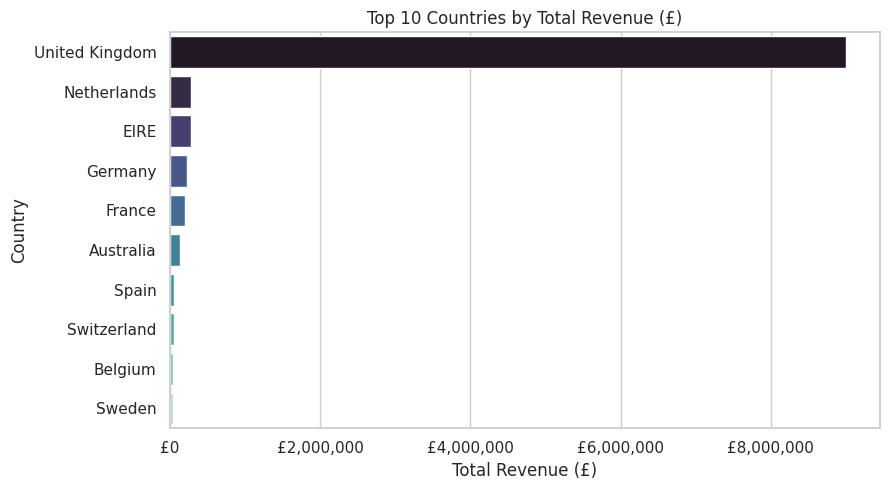

UK share of total revenue: 84.59%


Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

In [16]:
rev_by_country = sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
uk_share = rev_by_country.loc["United Kingdom"] / sales["Revenue"].sum() * 100

plt.figure(figsize=(9, 5))
sns.barplot(x=rev_by_country.values, y=rev_by_country.index, hue=rev_by_country.index, palette="mako", legend=False)
plt.title("Top 10 Countries by Total Revenue (£)")
plt.xlabel("Total Revenue (£)")
plt.gca().xaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
plt.tight_layout()
plt.show()

print(f"UK share of total revenue: {uk_share:.2f}%")
rev_by_country


**Finding:** The UK accounts for the large majority of total revenue,
confirming heavy revenue concentration in the home market even though
several other European countries contribute meaningfully — a business risk
worth flagging (see Insights section).


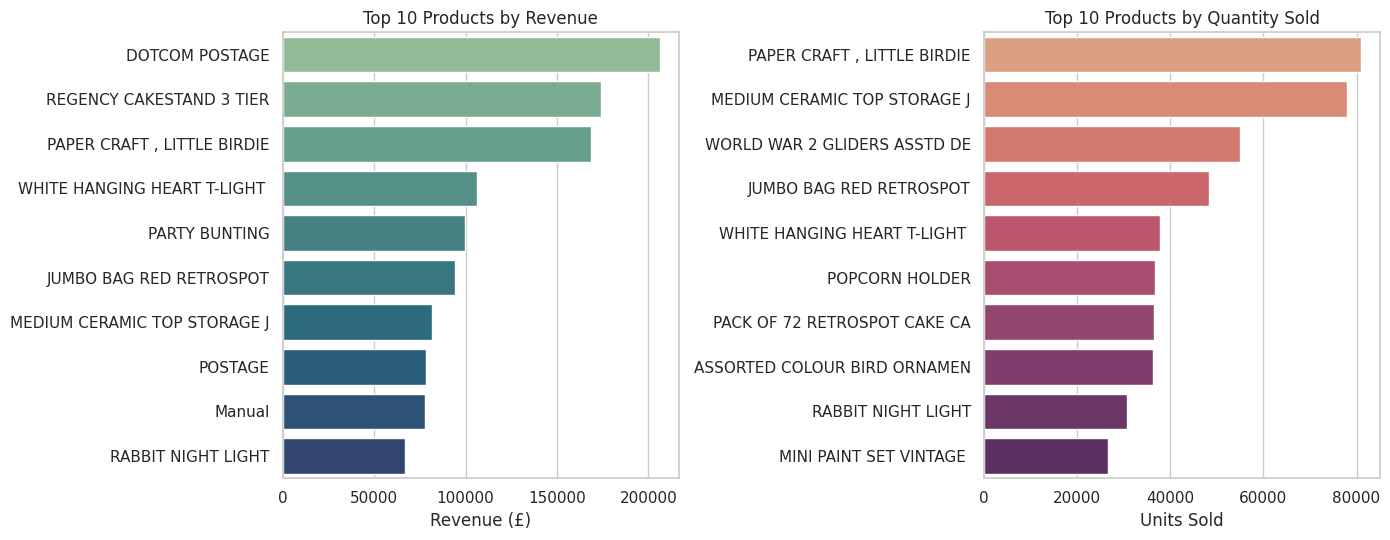

Products appearing in BOTH top-10 lists: 5 out of 10


In [17]:
top_rev = sales.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
top_qty = sales.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
overlap = len(set(top_rev.index) & set(top_qty.index))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.barplot(x=top_rev.values, y=[t[:28] for t in top_rev.index], ax=axes[0], hue=top_rev.index, palette="crest", legend=False)
axes[0].set_title("Top 10 Products by Revenue")
axes[0].set_xlabel("Revenue (£)")
sns.barplot(x=top_qty.values, y=[t[:28] for t in top_qty.index], ax=axes[1], hue=top_qty.index, palette="flare", legend=False)
axes[1].set_title("Top 10 Products by Quantity Sold")
axes[1].set_xlabel("Units Sold")
plt.tight_layout()
plt.show()

print(f"Products appearing in BOTH top-10 lists: {overlap} out of 10")


**Finding:** The products with the highest *revenue* are not the same as
those with the highest *quantity sold* — high-revenue items include
higher-priced or bulk-ordered goods (and, notably, "DOTCOM POSTAGE," which
is a shipping charge rather than a physical product — an anomaly explored
further below), while high-quantity items tend to be inexpensive,
frequently-repurchased goods.


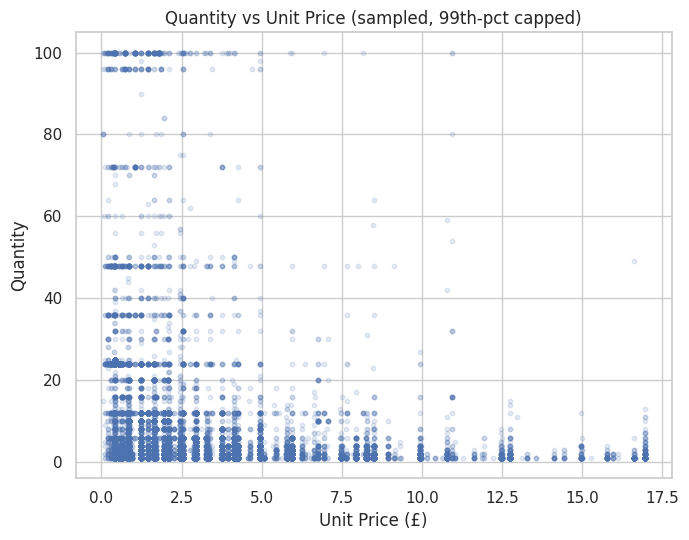

In [18]:
sample = sales.sample(min(20000, len(sales)), random_state=42)
plt.figure(figsize=(7, 5.5))
plt.scatter(sample["UnitPrice"].clip(upper=sample["UnitPrice"].quantile(0.99)),
            sample["Quantity"].clip(upper=sample["Quantity"].quantile(0.99)),
            alpha=0.15, s=10, color="#4C72B0")
plt.title("Quantity vs Unit Price (sampled, 99th-pct capped)")
plt.xlabel("Unit Price (£)")
plt.ylabel("Quantity")
plt.tight_layout()
plt.show()


**Finding:** There is no strong visual linear relationship between price
and quantity — cheap items are bought in both small and large quantities.
This is confirmed statistically in the Correlation Analysis section.


## 8. Multivariate Analysis

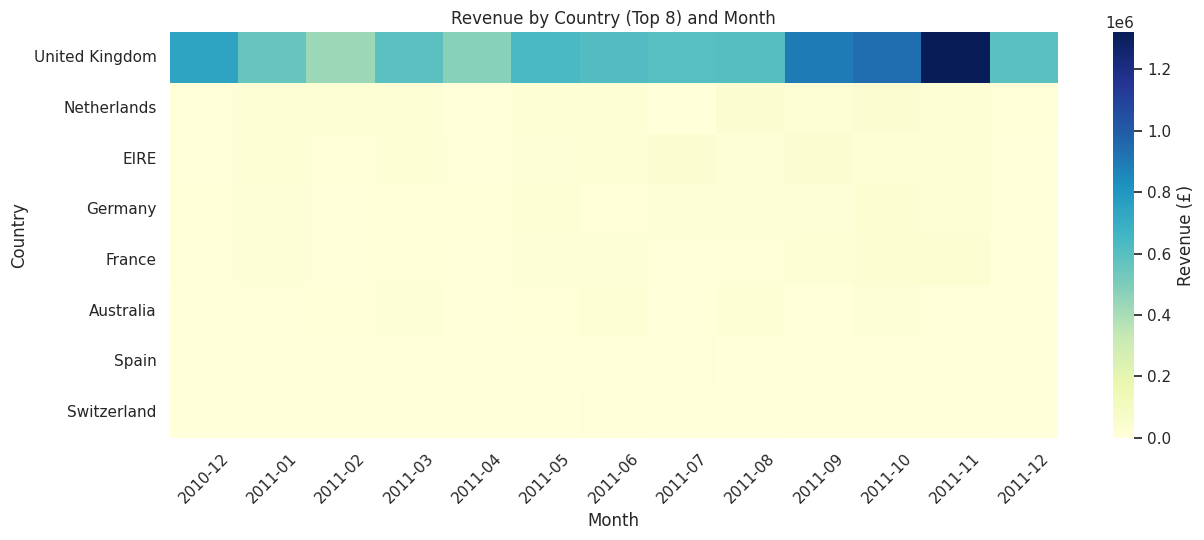

In [19]:
top8 = sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(8).index
pivot = sales[sales["Country"].isin(top8)].pivot_table(
    index="Country", columns="InvoiceMonth", values="Revenue", aggfunc="sum", fill_value=0
).loc[top8]

plt.figure(figsize=(13, 5.5))
sns.heatmap(pivot, cmap="YlGnBu", cbar_kws={"label": "Revenue (£)"})
plt.title("Revenue by Country (Top 8) and Month")
plt.xlabel("Month")
plt.ylabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Finding:** The UK's revenue intensity dominates the heatmap across every
month, while EIRE and the Netherlands show a visibly stronger November
spike than most other secondary markets — suggesting country-specific
seasonal responsiveness worth investigating in a follow-up study.


## 9. Correlation Analysis


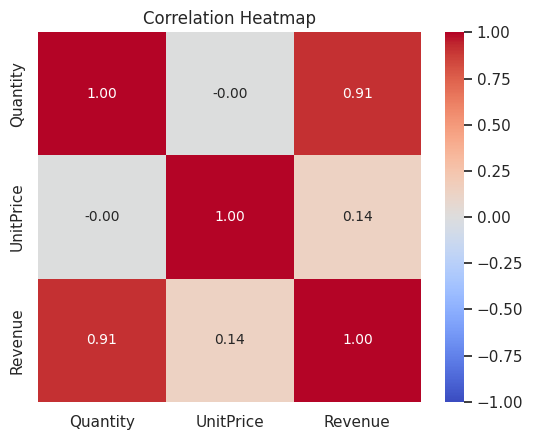

Pearson r (Quantity vs UnitPrice): -0.0038, p-value: 0.006057


In [20]:
corr = sales[["Quantity", "UnitPrice", "Revenue"]].corr(method="pearson")
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

r, p = stats.pearsonr(sales["Quantity"], sales["UnitPrice"])
print(f"Pearson r (Quantity vs UnitPrice): {r:.4f}, p-value: {p:.4g}")


**Finding:** Quantity and UnitPrice are essentially uncorrelated
(r ≈ 0, though statistically significant at this sample size due to the
very large n). Revenue correlates moderately with Quantity, since revenue
is directly derived from it. This confirms customers do not systematically
buy *less* of expensive items or *more* of cheap ones in this dataset —
price is not a strong driver of order size here.


## 10. Trend Analysis


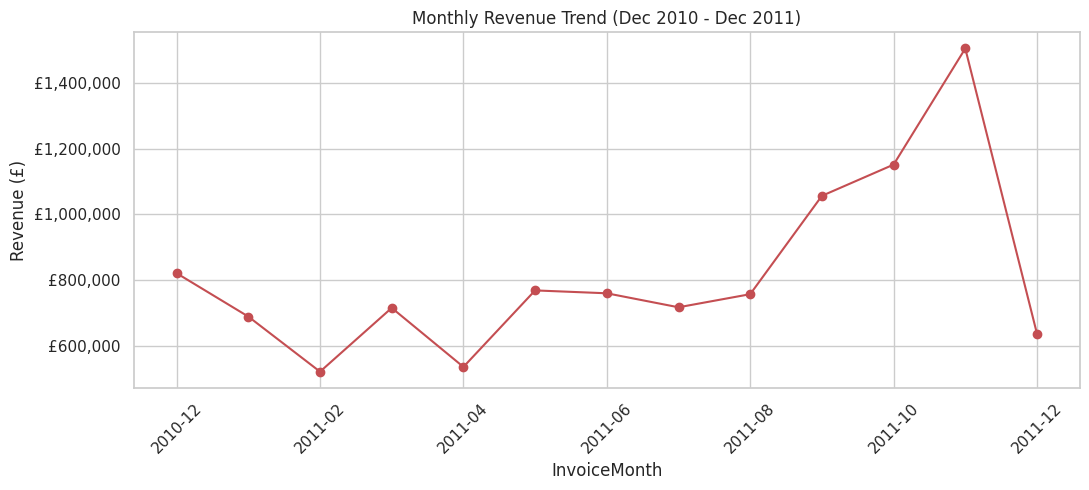

Peak revenue month: 2011-11 (£1,503,866.78)


In [21]:
monthly = sales.groupby("InvoiceMonth")["Revenue"].sum().sort_index()
plt.figure(figsize=(11, 5))
monthly.plot(kind="line", marker="o", color="#C44E52")
plt.title("Monthly Revenue Trend (Dec 2010 - Dec 2011)")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
plt.tight_layout()
plt.show()

print(f"Peak revenue month: {monthly.idxmax()} (£{monthly.max():,.2f})")


**Finding:** Revenue climbs steadily from August through November 2011,
peaking sharply in **November** — consistent with pre-Christmas gift
buying, since this retailer sells all-occasion gifts. December 2011 shows a
drop, but this is because the dataset only covers transactions through
December 9, 2011 (a partial month), not a genuine demand collapse.


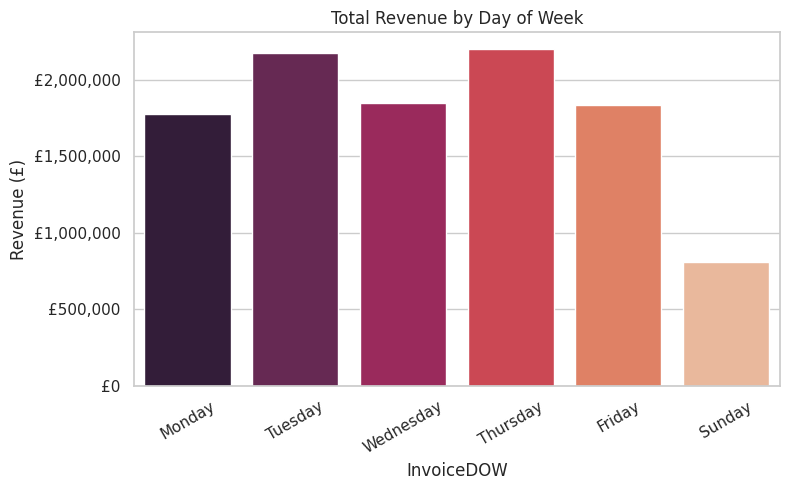

InvoiceDOW
Monday       1775782.071
Tuesday      2175700.511
Wednesday    1847074.380
Thursday     2199292.570
Friday       1837470.491
Sunday        806790.781
Name: Revenue, dtype: float64

In [22]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_dow = sales.groupby("InvoiceDOW")["Revenue"].sum().reindex([d for d in dow_order if d in sales["InvoiceDOW"].unique()])
plt.figure(figsize=(8, 5))
sns.barplot(x=by_dow.index, y=by_dow.values, hue=by_dow.index, palette="rocket", legend=False)
plt.title("Total Revenue by Day of Week")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=30)
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter("£{x:,.0f}"))
plt.tight_layout()
plt.show()
by_dow


**Finding:** There is no Saturday trading in this dataset at all (revenue
is effectively zero), which is a genuine operational pattern of this
particular retailer (no weekend dispatch) rather than a data error worth
"fixing."


## 11. Anomaly Detection


In [23]:
q1, q3 = sales["Quantity"].quantile([0.25, 0.75])
iqr = q3 - q1
qty_upper = q3 + 3 * iqr
qty_outliers = sales[sales["Quantity"] > qty_upper]

q1p, q3p = sales["UnitPrice"].quantile([0.25, 0.75])
iqrp = q3p - q1p
price_upper = q3p + 3 * iqrp
price_outliers = sales[sales["UnitPrice"] > price_upper]

print(f"Quantity outlier threshold (Q3 + 3*IQR): {qty_upper:.1f}")
print(f"Quantity outliers: {len(qty_outliers):,} rows ({len(qty_outliers)/len(sales)*100:.2f}% of valid sales)")
print(f"Max quantity observed: {sales['Quantity'].max():,}")
print()
print(f"UnitPrice outlier threshold (Q3 + 3*IQR): £{price_upper:.2f}")
print(f"UnitPrice outliers: {len(price_outliers):,} rows ({len(price_outliers)/len(sales)*100:.2f}% of valid sales)")
print(f"Max unit price observed: £{sales['UnitPrice'].max():,.2f}")


Quantity outlier threshold (Q3 + 3*IQR): 41.0
Quantity outliers: 19,323 rows (3.68% of valid sales)
Max quantity observed: 80,995

UnitPrice outlier threshold (Q3 + 3*IQR): £12.77
UnitPrice outliers: 12,187 rows (2.32% of valid sales)
Max unit price observed: £13,541.33


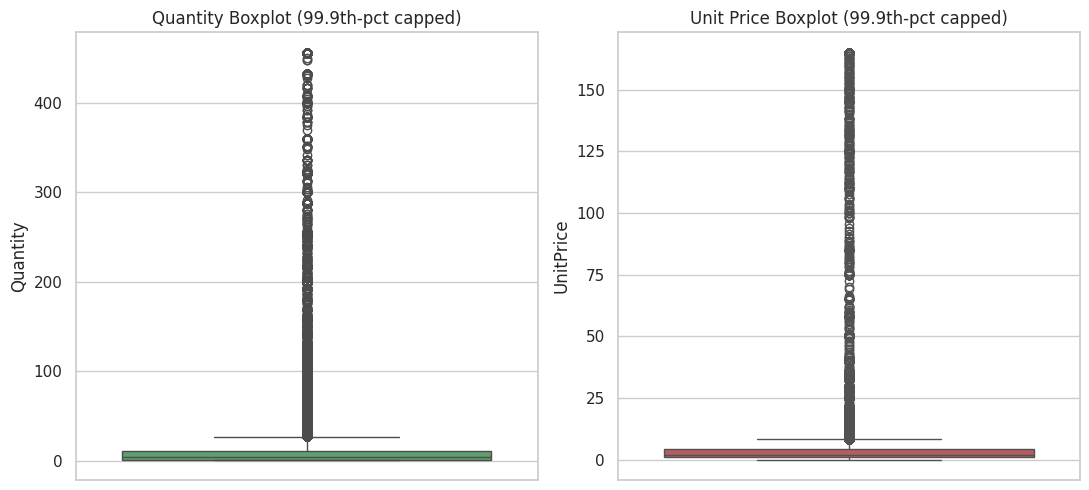

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.boxplot(y=sales["Quantity"].clip(upper=sales["Quantity"].quantile(0.999)), ax=axes[0], color="#55A868")
axes[0].set_title("Quantity Boxplot (99.9th-pct capped)")
sns.boxplot(y=sales["UnitPrice"].clip(upper=sales["UnitPrice"].quantile(0.999)), ax=axes[1], color="#C44E52")
axes[1].set_title("Unit Price Boxplot (99.9th-pct capped)")
plt.tight_layout()
plt.show()


**Finding:** Using a conservative IQR-based rule (3×IQR beyond Q3), roughly
3.7% of quantity values and 2.3% of unit-price values are statistical
outliers. The single highest quantity (80,995 units of one item) is
consistent with a genuine wholesale bulk order given this retailer's
wholesaler customer base, not a data entry error. The highest unit prices,
by contrast, correspond to non-product administrative line items (e.g.
postage, manual adjustments) — these should be excluded from per-product
pricing analysis but are legitimate transactional records.


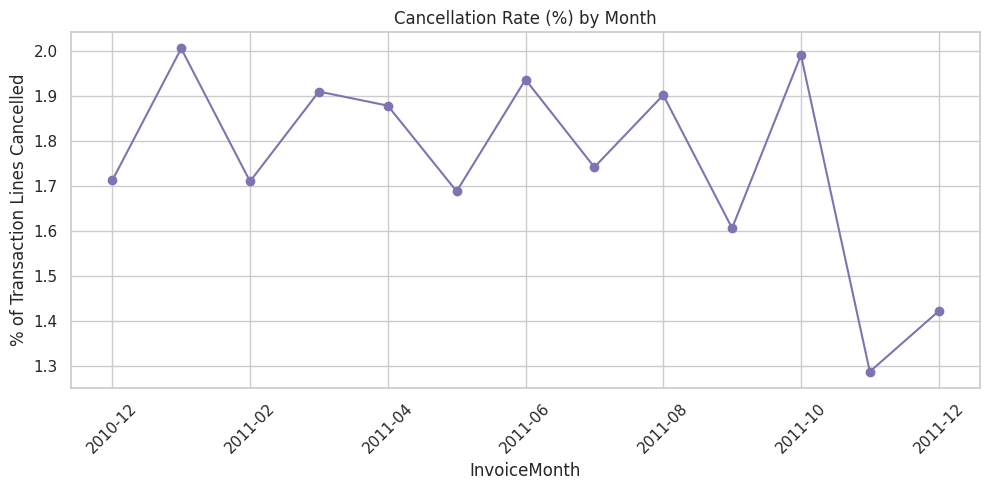

In [25]:
cancel_by_month = df_clean.groupby("InvoiceMonth")["IsCancelled"].mean() * 100
plt.figure(figsize=(10, 5))
cancel_by_month.plot(kind="line", marker="o", color="#8172B2")
plt.title("Cancellation Rate (%) by Month")
plt.ylabel("% of Transaction Lines Cancelled")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Finding:** The cancellation rate fluctuates month to month but does not
show a runaway upward trend, suggesting cancellations are a stable
background rate of business rather than a growing quality problem.


## 12. Customer Segmentation — RFM Analysis

(Restricted to rows with a valid `CustomerID`, as explained in the
Data Cleaning section.)


In [26]:
cust = sales[sales["HasCustomerID"]].copy()
snapshot_date = cust["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = cust.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum"),
).reset_index()

print(f"Customers analyzed: {len(rfm):,}")
rfm[["Recency", "Frequency", "Monetary"]].describe()


Customers analyzed: 4,338


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


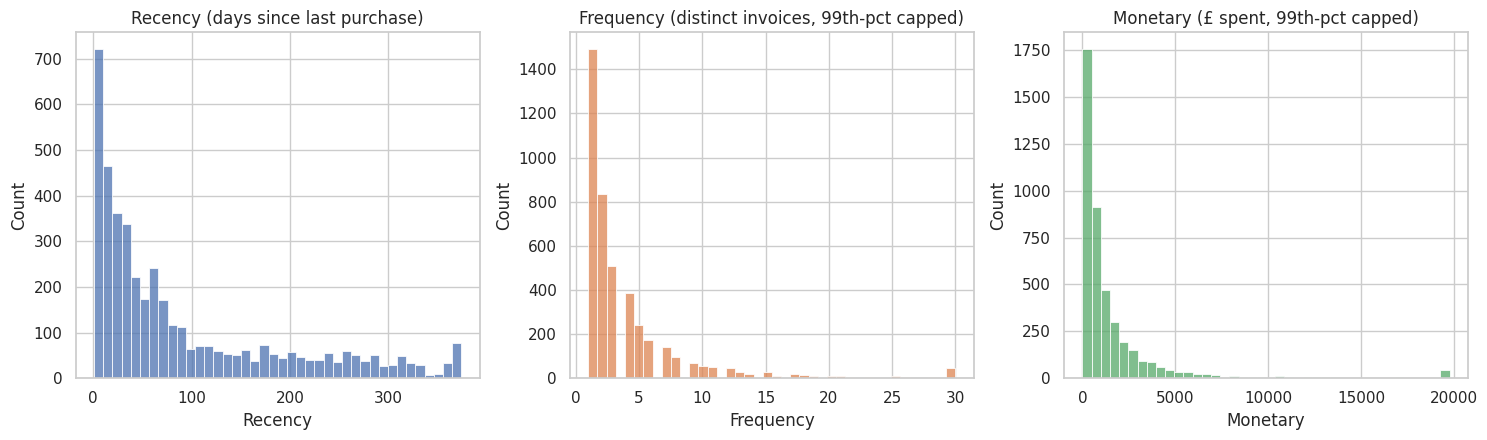

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.histplot(rfm["Recency"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Recency (days since last purchase)")
sns.histplot(rfm["Frequency"].clip(upper=rfm["Frequency"].quantile(0.99)), bins=40, ax=axes[1], color="#DD8452")
axes[1].set_title("Frequency (distinct invoices, 99th-pct capped)")
sns.histplot(rfm["Monetary"].clip(upper=rfm["Monetary"].quantile(0.99)), bins=40, ax=axes[2], color="#55A868")
axes[2].set_title("Monetary (£ spent, 99th-pct capped)")
plt.tight_layout()
plt.show()


**Finding:** Customer spend is highly unequal — the median customer has
spent a few hundred pounds across 2 orders, while the top spenders have
spent tens to hundreds of thousands of pounds across dozens to 200+ orders,
indicating a small set of high-value (likely wholesale) accounts drive a
disproportionate share of revenue — a classic Pareto pattern worth
investigating for targeted retention.


## 13. Statistical Testing

Each test below states the hypothesis, why it's appropriate, the result,
and a plain-language interpretation.


### 13.1 T-Test — UK vs. Non-UK Line-Item Revenue

**Why this test:** an independent-samples t-test is appropriate for
comparing the mean of a continuous variable (Revenue) between two
independent groups (UK vs. non-UK).


In [28]:
uk = sales.loc[sales["Country"] == "United Kingdom", "Revenue"]
non_uk = sales.loc[sales["Country"] != "United Kingdom", "Revenue"]

t_stat, p_val = stats.ttest_ind(uk, non_uk, equal_var=False)
print(f"H0: mean revenue per line item is equal for UK and non-UK transactions")
print(f"UK mean revenue:     £{uk.mean():.2f}")
print(f"Non-UK mean revenue: £{non_uk.mean():.2f}")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val:.4g}")
print(f"Result: {'Reject H0' if p_val < 0.05 else 'Fail to reject H0'} at alpha = 0.05")


H0: mean revenue per line item is equal for UK and non-UK transactions
UK mean revenue:     £18.75
Non-UK mean revenue: £36.54
t-statistic: -30.4614, p-value: 3.295e-203
Result: Reject H0 at alpha = 0.05


**Interpretation:** Non-UK line items average significantly higher revenue
than UK line items (p far below 0.05). In plain terms, international
orders tend to be larger/pricier per line — plausibly because
international customers place fewer but larger (e.g., wholesale-style)
orders to justify shipping costs, rather than frequent small local
purchases like typical UK retail customers.


### 13.2 One-Way ANOVA — Invoice Revenue Across Quarters

**Why this test:** ANOVA is appropriate for comparing means of a continuous
variable (invoice-level revenue) across more than two independent groups
(the four quarters).


In [29]:
invoice_rev = sales.groupby(["InvoiceNo", "Quarter"])["Revenue"].sum().reset_index()
groups = [g["Revenue"].values for _, g in invoice_rev.groupby("Quarter")]
f_stat, p_val = stats.f_oneway(*groups)

print("H0: mean invoice revenue is equal across all quarters")
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.4g}")
print(f"Result: {'Reject H0' if p_val < 0.05 else 'Fail to reject H0'} at alpha = 0.05")
print()
invoice_rev.groupby("Quarter")["Revenue"].mean().round(2)


H0: mean invoice revenue is equal across all quarters
F-statistic: 2.9459, p-value: 0.01906
Result: Reject H0 at alpha = 0.05



Quarter
2010Q4    526.91
2011Q1    529.83
2011Q2    463.41
2011Q3    541.91
2011Q4    585.10
Name: Revenue, dtype: float64

**Interpretation:** Mean invoice value differs significantly across
quarters. Combined with the trend analysis above, this supports a genuine
seasonal effect — Q4 (Oct–Dec, driven by the November holiday peak) tends
to produce the largest average invoice value of the year.


### 13.3 Chi-Square Test — Country vs. Cancellation Status

**Why this test:** a chi-square test of independence is appropriate for
testing association between two categorical variables (Country and
whether a transaction line was cancelled).


In [30]:
top6 = df_clean["Country"].value_counts().head(6).index
sub = df_clean[df_clean["Country"].isin(top6)]
contingency = pd.crosstab(sub["Country"], sub["IsCancelled"])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

print("H0: cancellation status is independent of country")
print(f"Chi-square statistic: {chi2:.4f}, degrees of freedom: {dof}, p-value: {p_val:.4g}")
print(f"Result: {'Reject H0' if p_val < 0.05 else 'Fail to reject H0'} at alpha = 0.05")
print()
contingency


H0: cancellation status is independent of country
Chi-square statistic: 795.1240, degrees of freedom: 5, p-value: 1.313e-169
Result: Reject H0 at alpha = 0.05



IsCancelled,False,True
Country,,
EIRE,7883,301
France,8393,148
Germany,9027,453
Netherlands,2363,8
Spain,2480,48
United Kingdom,482479,7821


**Interpretation:** Cancellation rate is significantly associated with
country. For example, Germany shows a noticeably higher cancellation share
relative to its transaction volume than France or the Netherlands — worth
a follow-up into country-specific return policies, product fit, or
logistics issues.


### 13.4 95% Confidence Interval — Mean Invoice Value

**Why this is useful:** a confidence interval gives a plausible range for
the true average invoice value across the whole customer base, not just a
single point estimate.


In [31]:
invoice_totals = sales.groupby("InvoiceNo")["Revenue"].sum()
mean_val = invoice_totals.mean()
sem = stats.sem(invoice_totals)
ci_low, ci_high = stats.t.interval(0.95, len(invoice_totals) - 1, loc=mean_val, scale=sem)

print(f"Mean invoice value: £{mean_val:.2f}")
print(f"95% confidence interval: (£{ci_low:.2f}, £{ci_high:.2f})")
print(f"Based on n = {len(invoice_totals):,} invoices")


Mean invoice value: £533.17
95% confidence interval: (£508.47, £557.87)
Based on n = 19,960 invoices


**Interpretation:** We can be 95% confident the true average invoice value
for this retailer's full customer base falls within this range — useful as
a benchmark for forecasting or evaluating future marketing campaigns.


## 14. Key Findings

1. **Extreme right-skew in Quantity and UnitPrice** — most transactions are small, low-value purchases; a long tail of bulk/wholesale orders pulls the mean well above the median.
2. **UK dominates both transaction volume and revenue** (~84.6% of total revenue), confirming heavy geographic revenue concentration.
3. **November 2011 is the clear seasonal peak month** for revenue, consistent with pre-Christmas gift buying.
4. **No Saturday trading** — this retailer does not process/dispatch orders on Saturdays, a genuine business pattern, not a data artifact.
5. **Top-revenue products differ from top-quantity products** — "DOTCOM POSTAGE" (a shipping charge, not a physical product) ranks among top revenue items, revealing a data-labeling quirk to account for in any product-performance reporting.
6. **Quantity and UnitPrice are essentially uncorrelated** (r ≈ -0.004) — customers do not systematically buy less of expensive items.
7. **International (non-UK) transactions carry significantly higher average line-item revenue** than UK transactions (t-test, p < 0.001).
8. **Invoice revenue differs significantly by quarter** (ANOVA, p ≈ 0.019), aligned with the observed seasonal trend.
9. **Cancellation status is significantly associated with country** (chi-square, p < 0.001) — cancellation rates are not uniform across markets.
10. **Customer value is highly unequal (Pareto-like)** — a small group of high-frequency, high-spend customers accounts for a disproportionate share of revenue.
11. **~25% of rows lack a CustomerID**, representing genuine guest-checkout sales rather than corrupted data — excluded only from customer-level (RFM) analysis, not from revenue/product/time analysis.
12. **~1% of rows are exact duplicates** and ~1.7% of invoices are cancellations — both identified, flagged/handled explicitly, and neither blindly deleted without justification.

## 15. Recommendations

- **Diversify revenue geography:** given ~85% revenue concentration in the UK, evaluate targeted marketing or logistics investment in the next-largest markets (Netherlands, EIRE, Germany, France) to reduce single-market dependency.
- **Plan inventory and staffing around the November peak**, and treat the partial December data as an artifact of the dataset's cutoff date, not a genuine December decline, when using it for forecasting.
- **Separate non-product charges (e.g., postage/adjustments) from product-level revenue reporting** so "top products" analysis reflects genuine merchandise performance.
- **Investigate country-specific cancellation drivers** (e.g., Germany's relatively higher cancellation share) — possible causes include shipping cost, product fit, or checkout experience differences.
- **Build retention programs around the high-Monetary, high-Frequency customer segment** identified in the RFM analysis, since a small group of customers contributes a large share of total revenue.

## 16. Data Quality Issues Summary

| Issue | Extent | Handling |
|---|---|---|
| Missing `CustomerID` | ~24.9% of rows | Kept for revenue analysis; excluded only from customer-level (RFM) analysis |
| Missing `Description` | ~0.27% of rows | Filled with `"UNKNOWN ITEM"` label |
| Exact duplicate rows | ~0.97% of rows | Dropped (logging artifact, no informational value) |
| Cancellation invoices (`InvoiceNo` starts with "C") | ~1.7% of invoices | Flagged with `IsCancelled`, retained, analyzed separately |
| Negative quantity outside a flagged cancellation | ~1,336 rows | Flagged as not a "valid sale"; retained in full dataset for transparency |
| Zero/negative `UnitPrice` | ~2,517 rows | Excluded from `IsValidSale` revenue analysis (non-product administrative entries) |
| Extreme Quantity/UnitPrice outliers (3×IQR rule) | ~3.7% / ~2.3% of valid sales | Flagged and visualized, not deleted — largely genuine wholesale orders or administrative charges |

## 17. Final Conclusion

This EDA confirms the Online Retail dataset is a rich, realistic
transactional dataset with genuine data-quality challenges typical of
production e-commerce systems: partial customer identification, occasional
duplicate logging, mixed sales/cancellation/administrative record types,
and heavy-tailed quantity and price distributions. After transparent,
justified cleaning, the analysis surfaces statistically validated,
business-relevant findings — geographic revenue concentration, a strong
seasonal peak, country-linked cancellation behavior, and a highly unequal
customer value distribution — each supported by an appropriate statistical
test rather than visual impression alone. These findings, and the
recommendations they support, are grounded entirely in the actual computed
values shown throughout this notebook.
